# PlasmaCast: Exploratory Data Analysis
**Contributor:** Puranjay Wadhera (GitHub: @PW13052003)

**File:** eda.ipynb

**Purpose:** To perform exploratory data analysis of the synthetic plasma donor dataset to understand patterns in donor behavior across 10 US cities.

**GitHub:** https://github.com/PW13052003/plasmacast/blob/main/notebooks/eda.ipynb

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the raw donor dataset
df = pd.read_csv("../src/data/donor_data.csv")
df["date"] = pd.to_datetime(df["date"])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Cities: {sorted(df['city'].unique())}")
print(f"Total rows: {len(df):,}")

Dataset shape: (14610, 8)
Date range: 2020-01-01 00:00:00 to 2023-12-31 00:00:00
Cities: ['Chicago', 'Dallas', 'Houston', 'Jacksonville', 'Los Angeles', 'New York City', 'Philadelphia', 'Phoenix', 'San Antonio', 'San Diego']
Total rows: 14,610


## 1. Dataset Overview

In [27]:
print("BASIC STATISTICS")
print(f"Total records:     {len(df):,}")
print(f"Number of cities:  {df['city'].nunique()}")
print(f"Date range:        {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Days per city:     {len(df) // df['city'].nunique():,}")

print("\nDONOR COUNT STATISTICS")
print(df['donor_count'].describe().round(2))

print("\nAVERAGE DONORS PER CITY")
print(df.groupby('city')['donor_count'].mean().round(1).sort_values(ascending=False))

BASIC STATISTICS
Total records:     14,610
Number of cities:  10
Date range:        2020-01-01 to 2023-12-31
Days per city:     1,461

DONOR COUNT STATISTICS
count    14610.00
mean        87.46
std         76.26
min          9.00
25%         44.00
50%         60.00
75%         97.00
max        401.00
Name: donor_count, dtype: float64

AVERAGE DONORS PER CITY
city
New York City    282.1
Los Angeles      136.7
Chicago           88.2
Houston           80.6
Phoenix           54.3
Philadelphia      53.0
San Antonio       50.8
San Diego         49.8
Dallas            44.2
Jacksonville      34.8
Name: donor_count, dtype: float64


## 2. Donor Count by Day of Week

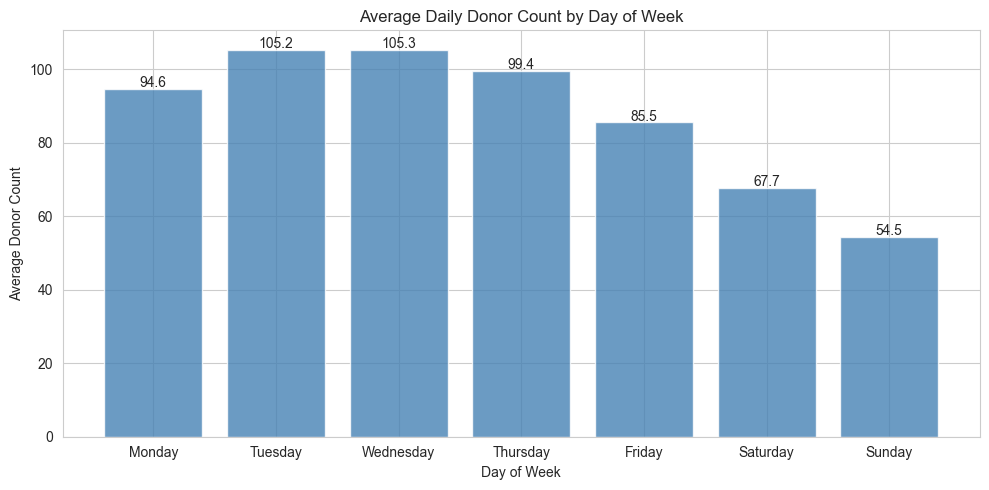

In [28]:
day_names = {0: "Monday", 1: "Tuesday", 2: "Wednesday",
             3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

day_avg = df.groupby("day_of_week")["donor_count"].mean().reset_index()
day_avg["day_name"] = day_avg["day_of_week"].map(day_names)

plt.figure(figsize=(10, 5))
bars = plt.bar(day_avg["day_name"], day_avg["donor_count"],
               color="steelblue", alpha=0.8)

for bar, val in zip(bars, day_avg["donor_count"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}", ha="center", fontsize=10)

plt.title("Average Daily Donor Count by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Donor Count")
plt.tight_layout()
plt.show()

**Observation:** From the data, it is clear that Tuesday and Wednesday are the peak donation days, whereas Saturday and Sunday see a major drop in the donor counts. This weekly pattern is one of the strongest signals in the dataset and is captured by the `day_of_week` and `is_weekend` features.

## 3. Donor Count by Month

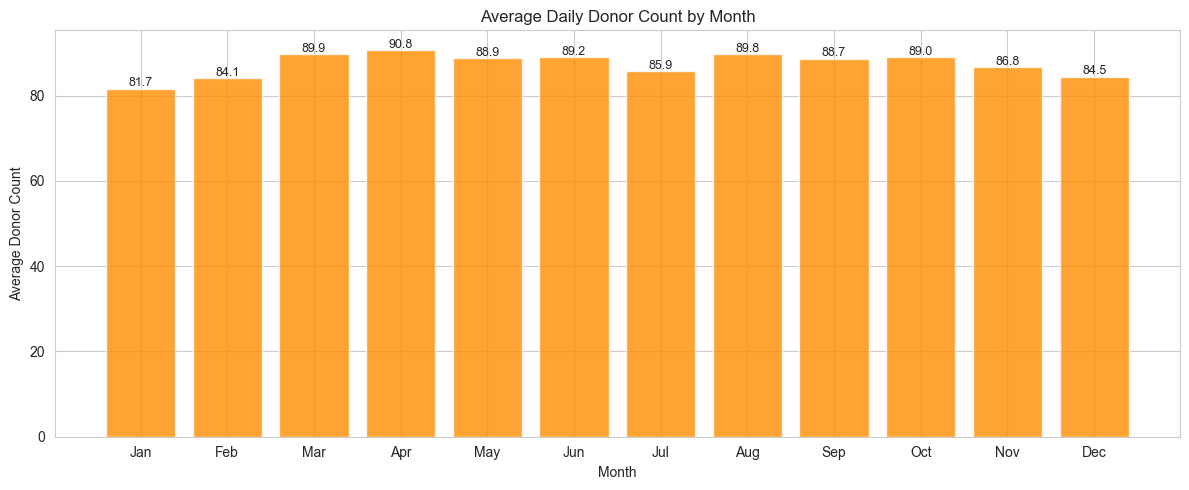

In [29]:
month_names = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
               7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

# Derive month directly from the date column
df["month"] = df["date"].dt.month

month_avg = df.groupby("month")["donor_count"].mean().reset_index()
month_avg["month_name"] = month_avg["month"].map(month_names)

plt.figure(figsize=(12, 5))
bars = plt.bar(month_avg["month_name"], month_avg["donor_count"],
               color="darkorange", alpha=0.8)

for bar, val in zip(bars, month_avg["donor_count"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}", ha="center", fontsize=9)

plt.title("Average Daily Donor Count by Month")
plt.xlabel("Month")
plt.ylabel("Average Donor Count")
plt.tight_layout()
plt.show()

**Observation:** Seasonal patterns exist, but aren't as important as the donor counts by day of the week because we see relatively low variations.

## 4. Weather Effects on Donor Count

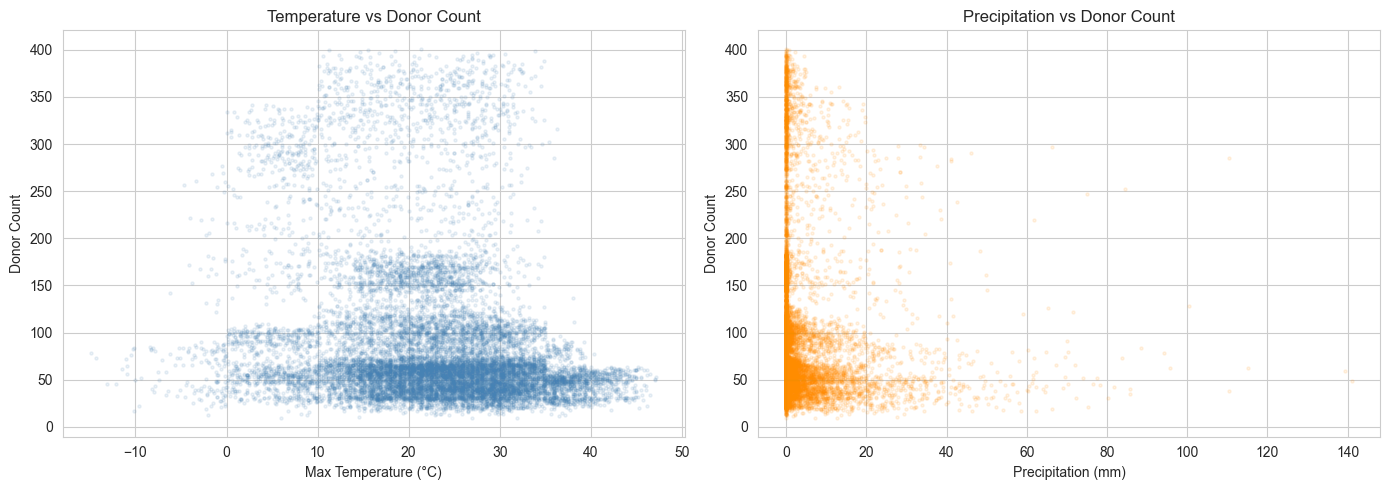

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Temperature vs donor count
ax1.scatter(df["temp_max"], df["donor_count"],
            alpha=0.1, s=5, color="steelblue")
ax1.set_xlabel("Max Temperature (°C)")
ax1.set_ylabel("Donor Count")
ax1.set_title("Temperature vs Donor Count")

# Precipitation vs donor count
ax2.scatter(df["precipitation"], df["donor_count"],
            alpha=0.1, s=5, color="darkorange")
ax2.set_xlabel("Precipitation (mm)")
ax2.set_ylabel("Donor Count")
ax2.set_title("Precipitation vs Donor Count")

plt.tight_layout()
plt.show()

**Observation:** Both weather variables show the expected relationships. Extreme temperatures, high or low show reduced donor counts. As far as precipitation is concerned, donor counts are inversely proportional to the amount of precipitation.

## 5. Holiday Effect

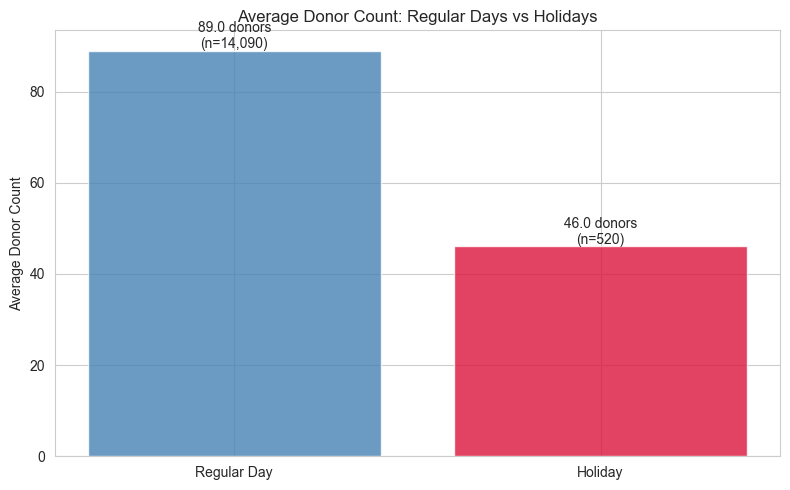

In [31]:
holiday_avg = df.groupby("is_holiday")["donor_count"].agg(["mean", "count"]).reset_index()
holiday_avg["label"] = holiday_avg["is_holiday"].map({0: "Regular Day", 1: "Holiday"})

plt.figure(figsize=(8, 5))
bars = plt.bar(holiday_avg["label"], holiday_avg["mean"],
               color=["steelblue", "crimson"], alpha=0.8)

for bar, val, count in zip(bars, holiday_avg["mean"], holiday_avg["count"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f} donors\n(n={count:,})", ha="center", fontsize=10)

plt.title("Average Donor Count: Regular Days vs Holidays")
plt.ylabel("Average Donor Count")
plt.tight_layout()
plt.show()

**Observation:** Federal holidays reduce average donor counts by approximately 48%. This is one of the strongest single factors in the dataset and confirms that the `is_holiday` feature carries significant predictive power. The 520 holiday observations across 4 years and 10 cities provide sufficient data for the model to learn this pattern reliably.

## 6. Donor Count Distribution by City

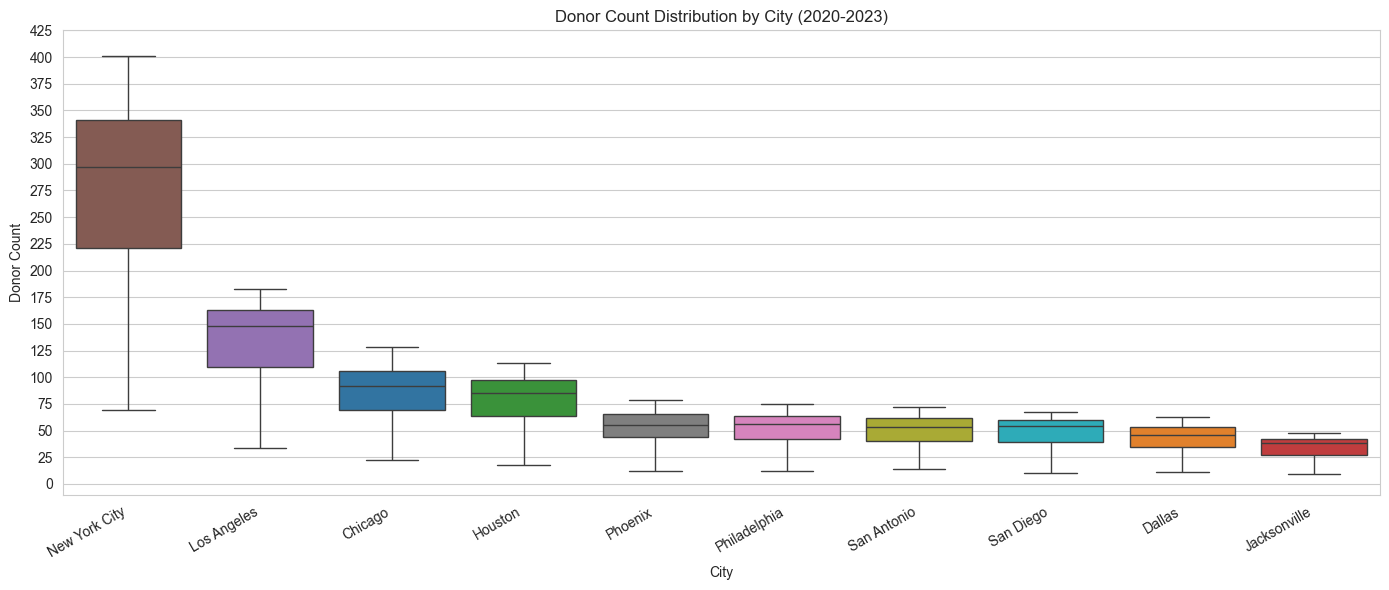

In [32]:
city_order = df.groupby("city")["donor_count"].mean().sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="city", y="donor_count", order=city_order,
            hue="city", palette="tab10", legend=False)
plt.title("Donor Count Distribution by City (2020-2023)")
plt.xlabel("City")
plt.ylabel("Donor Count")
plt.xticks(rotation=30, ha="right")

# Set Y axis to 25 unit intervals for clearer reading
max_val = df["donor_count"].max()
plt.yticks(range(0, int(max_val) + 25, 25))

plt.tight_layout()
plt.show()

**Observation:** Donor count distributions are proportional to city population
as designed. NYC shows the highest volume and widest variability (200-370 donors),
while Jacksonville is the most consistent and predictable (30-45 donors).
All cities show similar distribution shapes, confirming the model can apply
learned patterns uniformly across centers of different sizes.

## 7. Feature Correlation Heatmap

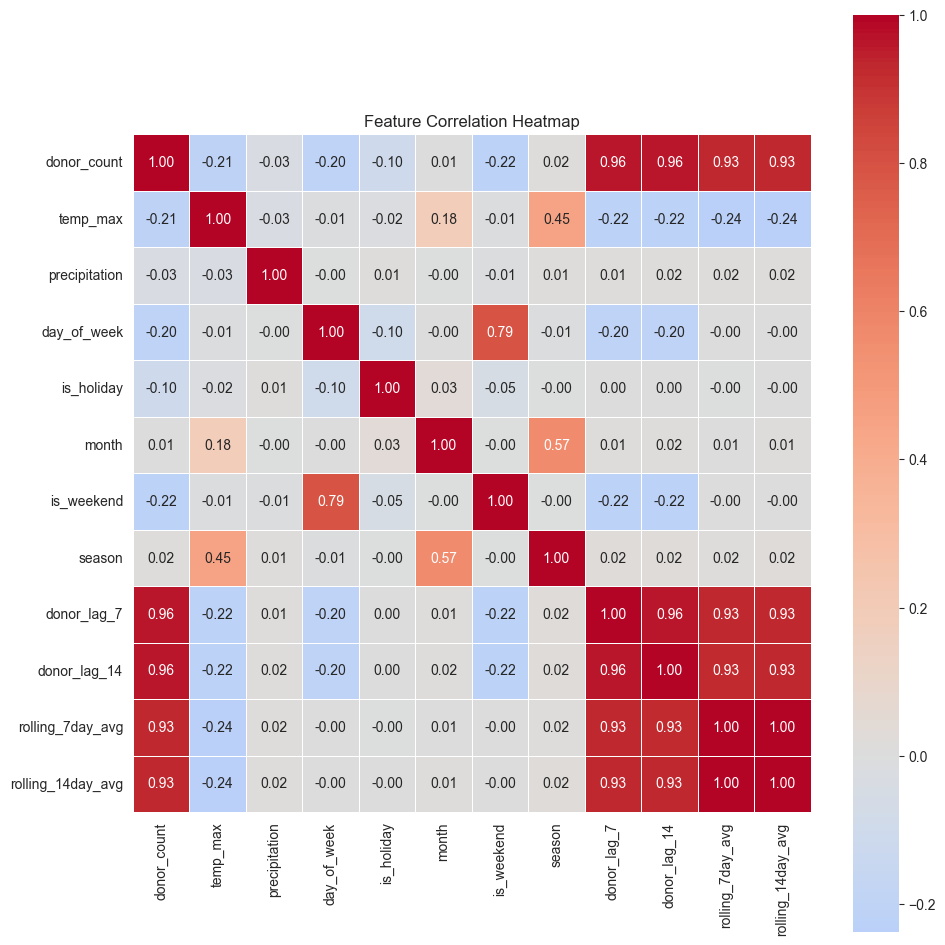

In [33]:
# Load featured dataset which has all engineered features
df_featured = pd.read_csv("../src/data/donor_data_featured.csv")

corr_features = ["donor_count", "temp_max", "precipitation", "day_of_week",
                 "is_holiday", "month", "is_weekend", "season",
                 "donor_lag_7", "donor_lag_14", "rolling_7day_avg", "rolling_14day_avg"]

corr_matrix = df_featured[corr_features].corr()

plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

**Observation:** The correlation heatmap reveals that lag and rolling average
features are by far the strongest predictors of donor count (0.93-0.96 correlation).
This validates our feature engineering decisions in features.py which stresses that recent donor
history is the most reliable signal available.